# HerdLine, goat counting

I count goats when they cross a line in a gate video. I do not save a permanent ID for each goat. The track ID only stops the same goat from being counted on every frame.



## 1. Setup

In [2]:
# detection and video packages
%pip install -q ultralytics opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from pathlib import Path

import cv2
from ultralytics import YOLO

# my project folder
PROJECT_ROOT = Path(r"C:/capstone")

DATASET_YAML = PROJECT_ROOT / "data" / "goat.yaml"
BASE_YOLO_MODEL = "yolov8n.pt"
TRAINED_MODEL_PATH = PROJECT_ROOT / "models" / "weights" / "best.pt"
TEST_VIDEO_PATH = PROJECT_ROOT / "data" / "videos" / "counting" / "your_video.mp4"
EXPECTED_GOAT_COUNT = 10
CONFIDENCE_THRESHOLD = 0.25

# vertical line, in pixels. My test clips are small, so 320 sits near the middle.
COUNTING_LINE_X = 320

# goats in the sample clip move left to right
CROSSING_DIRECTION = "left_to_right"

ANNOTATED_VIDEO_PATH = PROJECT_ROOT / "outputs" / "results" / "counted_output.mp4"
TRAIN_EPOCHS = 5
TRAIN_IMAGE_SIZE = 640
TRAIN_BATCH = 8

## 2. Data

I used the CherryChevre goat set. Each label is a YOLO box, and the only class is goat.

| Split | Images | Goat boxes |
| --- | ---: | ---: |
| Train | 4905 | 28099 |
| Valid | 616 | 3591 |
| Test | 636 | 3630 |

Most of my training images have several goats in one frame. That is harder for both the detector and the counter.

![How many goats per training image](figures/goats_per_image.png)

![Three training photos with the labeled boxes](figures/sample_labels.png)

I counted the label files and saved these two figures.


train: 4905 images, 28099 goat boxes
valid: 616 images, 3591 goat boxes
test: 636 images, 3630 goat boxes


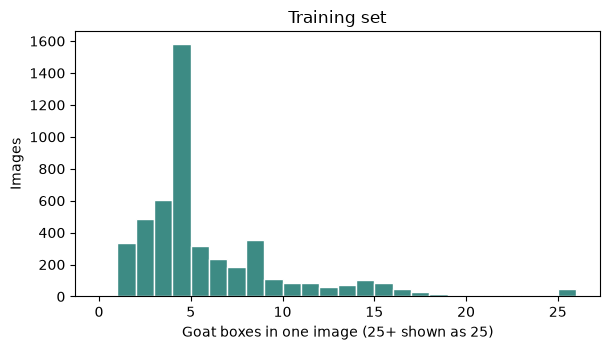

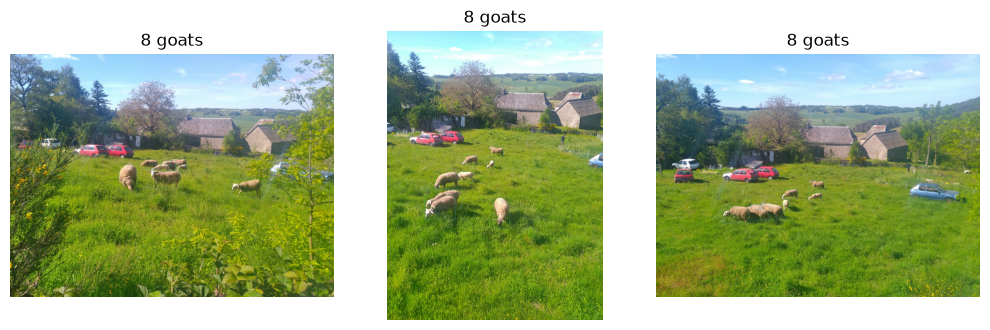

In [4]:
import matplotlib.pyplot as plt

def goat_boxes_per_image(label_dir):
    # one number per label file: how many goat boxes are in that image
    counts = []
    for path in Path(label_dir).glob("*.txt"):
        lines = [line for line in path.read_text(encoding="utf-8", errors="ignore").splitlines() if line.strip()]
        counts.append(len(lines))
    return counts

for split_name in ("train", "valid", "test"):
    image_dir = PROJECT_ROOT / "data" / split_name / "images"
    label_dir = PROJECT_ROOT / "data" / split_name / "labels"
    n_images = sum(1 for path in image_dir.iterdir() if path.is_file())
    box_counts = goat_boxes_per_image(label_dir)
    print(f"{split_name}: {n_images} images, {sum(box_counts)} goat boxes")

train_counts = goat_boxes_per_image(PROJECT_ROOT / "data" / "train" / "labels")
capped = [min(n, 25) for n in train_counts]
plt.figure(figsize=(6.2, 3.6))
plt.hist(capped, bins=range(0, 27), color="#3d8b84", edgecolor="white")
plt.xlabel("Goat boxes in one image (25+ shown as 25)")
plt.ylabel("Images")
plt.title("Training set")
plt.tight_layout()
plt.show()

# a few training photos with the boxes I trained on
picked = []
for label_path in sorted((PROJECT_ROOT / "data" / "train" / "labels").glob("*.txt")):
    lines = [line for line in label_path.read_text(encoding="utf-8", errors="ignore").splitlines() if line.strip()]
    if not lines:
        continue
    image_path = None
    for ext in (".jpg", ".jpeg", ".png", ".JPG"):
        candidate = PROJECT_ROOT / "data" / "train" / "images" / f"{label_path.stem}{ext}"
        if candidate.is_file():
            image_path = candidate
            break
    if image_path is not None:
        picked.append((image_path, lines))
    if len(picked) == 3:
        break

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, (image_path, lines) in zip(axes, picked):
    image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    height, width = image.shape[:2]
    for line in lines:
        parts = line.split()
        if len(parts) < 5:
            continue
        xc, yc, bw, bh = map(float, parts[1:5])
        x1 = int((xc - bw / 2) * width)
        y1 = int((yc - bh / 2) * height)
        x2 = int((xc + bw / 2) * width)
        y2 = int((yc + bh / 2) * height)
        cv2.rectangle(image, (x1, y1), (x2, y2), (61, 139, 132), 2)
    ax.imshow(image)
    ax.set_title(f"{len(lines)} goats")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Model

I used YOLOv8n, the small model. It reads the image at several sizes, then the detection head gives me a box and a class score.

- Activation in the network: SiLU.
- Loss I trained with: box location, class score, and distribution focal loss (how sure the box edges are).
- Optimizer: Ultralytics chose it (SGD or AdamW). I trained for 5 epochs, batch size 8, image size 640.
- One class: goat. A person in the frame can still get a goat box. That showed up on my gate videos.


## 4. Fine-tune the detector

I fine-tuned YOLOv8n on the goat labels for 5 epochs and saved the best weights to `models/weights/best.pt`.


In [8]:
def train_goat_detector(dataset_yaml, base_model, save_path, epochs, image_size, batch_size, project_root):
    """Fine-tune YOLO on my goat labels and keep the best weights."""
    save_path = Path(save_path)
    project_root = Path(project_root)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    model = YOLO(base_model)
    train_output = model.train(
        data=str(dataset_yaml),
        epochs=epochs,
        imgsz=image_size,
        batch=batch_size,
        project=str(project_root / "runs" / "detect"),
        name="goat_train",
        exist_ok=True,
        workers=0,
    )

    weights_folder = Path(train_output.save_dir) / "weights"
    best_weights = weights_folder / "best.pt"
    last_weights = weights_folder / "last.pt"

    if best_weights.is_file():
        source = best_weights
    elif last_weights.is_file():
        source = last_weights
    else:
        raise FileNotFoundError(f"No weights saved in {weights_folder}.")

    save_path.write_bytes(source.read_bytes())
    print("Copied", source, "to", save_path)
    return save_path


In [9]:
# this is the training run that produced best.pt
train_goat_detector(
    DATASET_YAML,
    BASE_YOLO_MODEL,
    TRAINED_MODEL_PATH,
    TRAIN_EPOCHS,
    TRAIN_IMAGE_SIZE,
    TRAIN_BATCH,
    PROJECT_ROOT,
)


New https://pypi.org/project/ultralytics/8.4.164 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.163  Python-3.13.13 torch-2.14.0+cpu CPU (Intel Core i5-10310U 1.70GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\capstone\data\goat.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt

WindowsPath('C:/capstone/models/weights/best.pt')

## 5. Detection scores on the test set

I scored the saved weights on the test split. This pass only measures the model.


In [5]:
def evaluate_detector(trained_model_path, dataset_yaml):
    """My precision, recall, and mAP on the test split."""
    model = YOLO(str(trained_model_path))
    metrics = model.val(data=str(dataset_yaml), split="test")
    box = metrics.box
    results = {
        "precision": float(box.mp),
        "recall": float(box.mr),
        "map50": float(box.map50),
        "map50_95": float(box.map),
    }
    for name, value in results.items():
        print(f"{name}: {value:.4f}")
    return results


In [6]:
# scores from best.pt on the test images
detection_scores = evaluate_detector(TRAINED_MODEL_PATH, DATASET_YAML)
precision = detection_scores["precision"]
recall = detection_scores["recall"]
f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
print(f"f1: {f1:.4f}")


Ultralytics 8.4.163  Python-3.13.13 torch-2.14.0+cpu CPU (Intel Core i5-10310U 1.70GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 555.2152.0 MB/s, size: 2212.4 KB)
val: Scanning C:\capstone\data\test\labels.cache... 636 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 636/636 98.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 1.7s/it 1:082.3sss
                   all        636       3630      0.897      0.738      0.822      0.492
Speed: 1.1ms preprocess, 61.1ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to C:\capstone\notebooks\runs\detect\val
precision: 0.8970
recall: 0.7377
map50: 0.8223
map50_95: 0.4917
f1: 0.8096


These are the scores I got on the test split (image size 640, weights in `models/weights/best.pt`, 5 epochs):

| Metric | Score |
| --- | ---: |
| Precision | 0.897 |
| Recall | 0.738 |
| F1 | 0.810 |
| mAP50 | 0.822 |
| mAP50-95 | 0.492 |

Precision is higher than recall, so on this set I miss goats more often than I invent them. My own gate videos are not in this dataset, so they still come out worse than these numbers.


## 6. Counting module

In [11]:
class CountingModule:
    """I count each track once, when it crosses my line."""

    def __init__(self, counting_line_x, crossing_direction="left_to_right"):
        self.counting_line_x = counting_line_x
        self.crossing_direction = crossing_direction
        self.counted_track_ids = set()
        self.previous_center_x = {}
        self.total_count = 0

    def has_crossed_line(self, track_id, center_x):
        """True if this track moved from one side of my line to the other."""
        if track_id in self.counted_track_ids:
            return False

        previous_x = self.previous_center_x.get(track_id)
        self.previous_center_x[track_id] = center_x

        if previous_x is None:
            return False

        line_x = self.counting_line_x
        if self.crossing_direction == "left_to_right":
            return previous_x < line_x <= center_x
        return previous_x > line_x >= center_x

    def add_goat_to_count(self, track_id):
        """I store the id so I do not count that goat again."""
        if track_id in self.counted_track_ids:
            return
        self.counted_track_ids.add(track_id)
        self.total_count += 1

    def get_total_count(self):
        """How many goats I have counted in this video."""
        return self.total_count


## 7. Count goats in a video

In [12]:
def open_video_reader(video_path):
    """I open the clip and read its width, height, and frame rate."""
    capture = cv2.VideoCapture(str(video_path))
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = capture.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 0:
        fps = 25
    return capture, width, height, fps


def create_video_writer(output_path, width, height, fps):
    """I write the annotated video to this path."""
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    return cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))


def draw_counting_overlay(frame, counting_line_x, total_count):
    """I draw the counting line and the running total on the frame."""
    height = frame.shape[0]
    cv2.line(frame, (counting_line_x, 0), (counting_line_x, height), (0, 255, 255), 2)
    cv2.putText(
        frame,
        f"Count: {total_count}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (0, 255, 0),
        2,
    )
    return frame


def get_box_center_x(box):
    """The horizontal center of the box. That is the point I use for the line."""
    x1, _, x2, _ = box
    return (x1 + x2) / 2


In [13]:
def run_counting_on_video(
    video_path,
    trained_model_path,
    counting_module,
    output_video_path,
    confidence_threshold,
):
    """I track goats frame by frame, count crossings, and save the annotated video."""
    model = YOLO(str(trained_model_path))
    capture, width, height, fps = open_video_reader(video_path)
    writer = create_video_writer(output_video_path, width, height, fps)

    while True:
        success, frame = capture.read()
        if not success:
            break

        track_result = model.track(
            frame,
            persist=True,
            conf=confidence_threshold,
            tracker="bytetrack.yaml",
            verbose=False,
        )[0]

        if track_result.boxes is not None and track_result.boxes.id is not None:
            track_ids = track_result.boxes.id.int().tolist()
            boxes = track_result.boxes.xyxy.cpu().tolist()
            for track_id, box in zip(track_ids, boxes):
                center_x = get_box_center_x(box)
                if counting_module.has_crossed_line(track_id, center_x):
                    counting_module.add_goat_to_count(track_id)

        annotated = track_result.plot()
        annotated = draw_counting_overlay(
            annotated,
            counting_module.counting_line_x,
            counting_module.get_total_count(),
        )
        writer.write(annotated)

    capture.release()
    writer.release()
    return counting_module.get_total_count()


## 8. Compare the count to the real number

In [14]:
class CountingResult:
    """My count for a clip, next to the number I counted by hand."""

    def __init__(self, system_count):
        self.system_count = system_count

    def build_report(self, expected_count):
        """expected_count is the number of goats I know are in this clip."""
        error = self.system_count - expected_count
        if expected_count == 0:
            accuracy = 0.0
        else:
            accuracy = max(0.0, 1.0 - abs(error) / expected_count)
        return {
            "expected_count": expected_count,
            "system_count": self.system_count,
            "counting_error": error,
            "counting_accuracy": accuracy,
        }


## 9. Count on a test video

I pointed this cell at a placeholder path, so the saved result is 0. I check real gate clips in the web app.


In [15]:
counter = CountingModule(COUNTING_LINE_X, CROSSING_DIRECTION)

final_count = run_counting_on_video(
    TEST_VIDEO_PATH,
    TRAINED_MODEL_PATH,
    counter,
    ANNOTATED_VIDEO_PATH,
    CONFIDENCE_THRESHOLD,
)

result = CountingResult(final_count)
report = result.build_report(EXPECTED_GOAT_COUNT)
print(report)

{'expected_count': 10, 'system_count': 0, 'counting_error': -10, 'counting_accuracy': 0.0}


## 10. Web app

I built a local site for the demo, not a cloud deploy.

I start it with `uvicorn web.app:app --reload --host 127.0.0.1 --port 8000` and open http://127.0.0.1:8000.

The farmer saves a herd size, uploads a gate video, and gets a count, a missing or extra note, and the annotated video. I store check-ins in the browser on that computer. I do not have a database yet.

I can move the same FastAPI app and `best.pt` to a small server later. For now I run it on my laptop.


### Summary

On the test images my F1 is about 0.81. Counting on my own gate videos is still weaker, because a goat's track id sometimes changes when it crosses the line.
